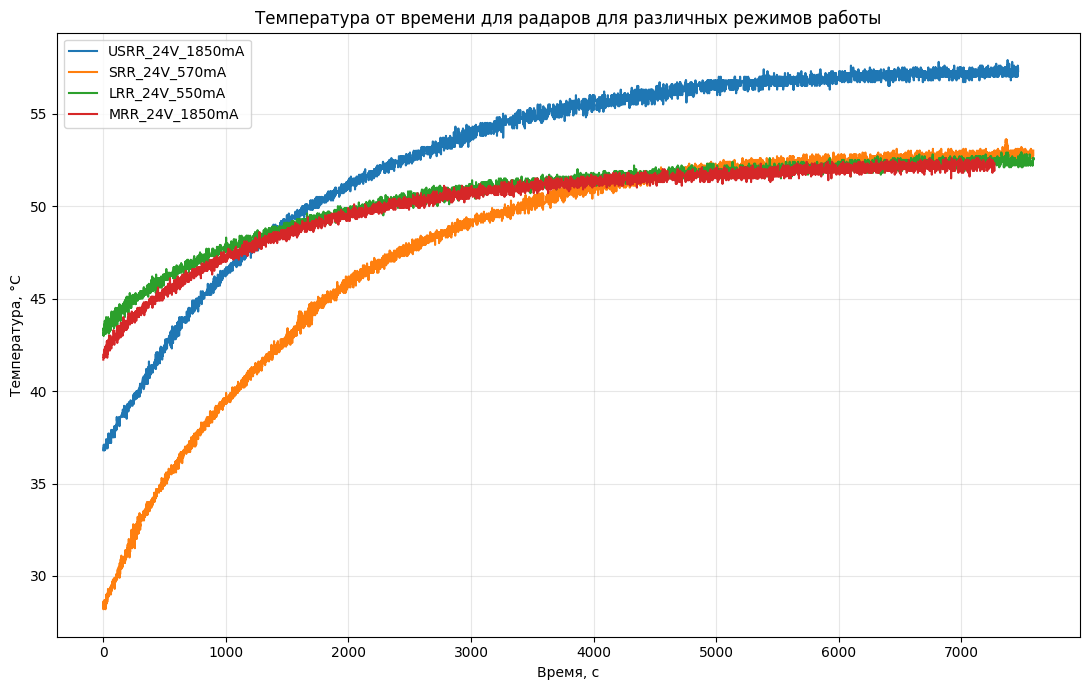

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Укажите явные пути к нужным CSV (можно оставить пустой строкой, если файл не нужен)
USRR_PATH = "USRR_24V_1850mA.csv"
SRR_PATH  = "SRR_24V_570mA.csv"
LRR_PATH  = "LRR_24V_550mA.csv"
MRR_PATH  = "MRR_24V_1850mA.csv"

# Формируем словарь файлов из заданных путей
files = {}
for p in [USRR_PATH, SRR_PATH, LRR_PATH, MRR_PATH]:
    if p and isinstance(p, str):
        path = Path(p)
        if path.exists():
            files[path.stem] = path

if not files:
    raise FileNotFoundError("Не указаны валидные пути к CSV файлам")


def load_time_and_temp(csv_path: Path):
    df = pd.read_csv(csv_path)

    # Determine time axis
    if "elapsed_seconds" in df.columns:
        t = pd.to_numeric(df["elapsed_seconds"], errors="coerce").astype(float)
    elif "timestamp_iso" in df.columns:
        ts = pd.to_datetime(df["timestamp_iso"], errors="coerce")
        t = (ts - ts.min()).dt.total_seconds()
    else:
        raise ValueError(f"Не найден столбец времени в {csv_path.name}")

    # Determine temperature column
    temp_col = None
    for candidate in ["cpuTemp", "temperature", "temp"]:
        if candidate in df.columns:
            temp_col = candidate
            break
    if temp_col is None:
        raise ValueError(f"Не найден столбец температуры в {csv_path.name}")

    y = pd.to_numeric(df[temp_col], errors="coerce")

    mask = t.notna() & y.notna()
    return t[mask].to_numpy(), y[mask].to_numpy()

plt.figure(figsize=(11, 7))
for label, path in files.items():
    t, y = load_time_and_temp(path)
    plt.plot(t, y, label=label)

plt.xlabel("Время, с")
plt.ylabel("Температура, °C")
plt.title("Температура от времени для радаров для различных режимов работы")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


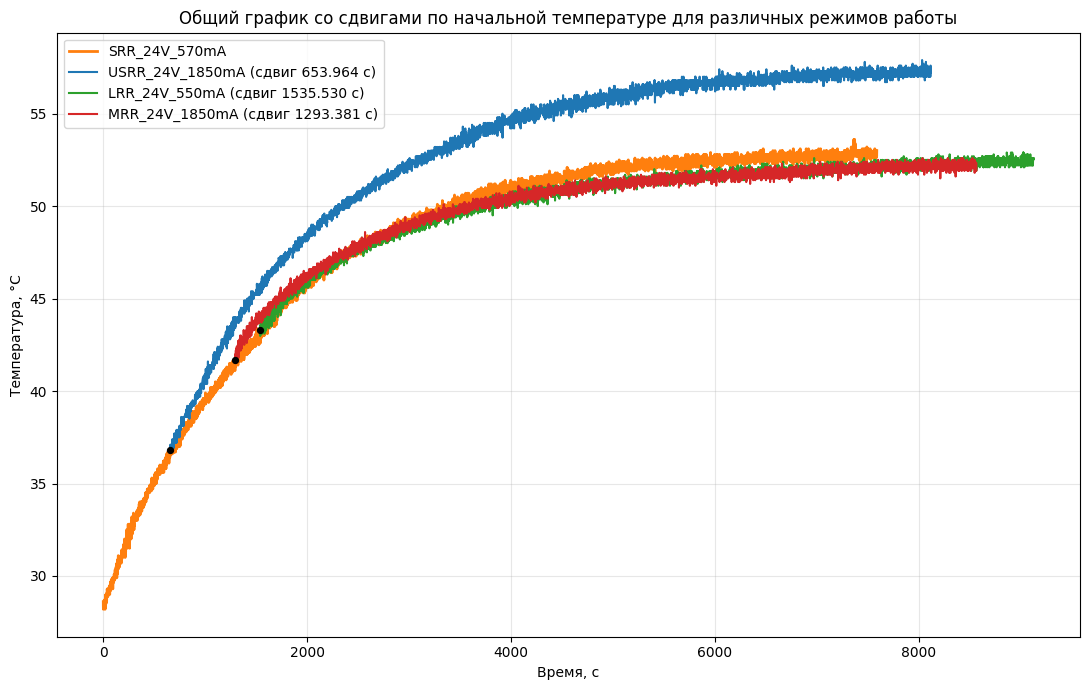

In [9]:
# Общий график: SRR как базовый (оранжевый),
# USRR/LRR/MRR сдвинуты так, чтобы их стартовая температура совпала
# с моментом на SRR с той же температурой
import numpy as np
import matplotlib.pyplot as plt

# Определяем базовый файл SRR
label_srr = next((k for k in files.keys() if k.startswith("SRR_")), None)
if label_srr is None:
    raise RuntimeError("Не найден файл SRR_*.csv для базового выравнивания")

# Список остальных для сдвига
others = [k for k in files.keys() if k != label_srr and (k.startswith("USRR_") or k.startswith("LRR_") or k.startswith("MRR_"))]
if not others:
    raise RuntimeError("Не найдены файлы USRR_/LRR_/MRR_ для выравнивания")

# Загрузка базовой кривой
t_srr, y_srr = load_time_and_temp(files[label_srr])

# Функция поиска сдвига по стартовой температуре A относительно SRR
def compute_shift_to_srr(t_a, y_a, t_srr, y_srr):
    idx_a0 = np.where(~np.isnan(y_a))[0]
    if len(idx_a0) == 0:
        raise ValueError("Кривая не содержит валидных температур")
    i0 = idx_a0[0]
    start_temp = y_a[i0]
    start_time_a = t_a[i0]

    valid_srr = ~np.isnan(y_srr)
    if not np.any(valid_srr):
        raise ValueError("SRR не содержит валидных температур")
    j_local = np.argmin(np.abs(y_srr[valid_srr] - start_temp))
    j = np.where(valid_srr)[0][j_local]

    t_align = t_srr[j]
    shift = t_align - start_time_a
    return shift, start_temp, t_align

plt.figure(figsize=(11, 7))
# Рисуем SRR как базовый
plt.plot(t_srr, y_srr, label=label_srr, color="C1", linewidth=2)

# Цвета для остальных
colors = {"USRR_": "C0", "LRR_": "C2", "MRR_": "C3"}

# Добавляем остальные со сдвигами
for label in others:
    t_a, y_a = load_time_and_temp(files[label])
    shift, temp0, t_align = compute_shift_to_srr(t_a, y_a, t_srr, y_srr)
    color = next((c for p, c in colors.items() if label.startswith(p)), None)
    plt.plot(t_a + shift, y_a, label=f"{label} (сдвиг {shift:.3f} с)", color=color)
    # отметка точки выравнивания
    plt.scatter([t_align], [temp0], color="black", s=18, zorder=5)

plt.xlabel("Время, с")
plt.ylabel("Температура, °C")
plt.title("Общий график со сдвигами по начальной температуре для различных режимов работы")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Оценка установившейся температуры: среднее по последним 60 сек для каждого графика
import numpy as np

results = []
for label, path in files.items():
    t, y = load_time_and_temp(path)
    if len(t) == 0:
        print(f"Нет данных: {label}")
        continue
    t_max = np.nanmax(t)
    window_start = max(0.0, t_max - 60.0)
    mask = (t >= window_start) & ~np.isnan(y)
    if not np.any(mask):
        print(f"Недостаточно валидных данных в окне: {label}")
        continue
    mean_temp = float(np.nanmean(y[mask]))
    n_points = int(np.sum(mask))
    results.append((label, mean_temp, window_start, t_max, n_points))

# Печать результатов
for label, mean_temp, t0, t1, n in results:
    print(f"{label}: средняя температура за последние 60 с = {mean_temp:.3f} °C (точек: {n}, окно: [{t0:.3f}, {t1:.3f}] с)")



USRR_24V_1850mA: средняя температура за последние 60 с = 57.267 °C (точек: 60, окно: [7404.104, 7464.104] с)
SRR_24V_570mA: средняя температура за последние 60 с = 52.820 °C (точек: 45, окно: [7527.363, 7587.363] с)
LRR_24V_550mA: средняя температура за последние 60 с = 52.438 °C (точек: 48, окно: [7529.263, 7589.263] с)
MRR_24V_1850mA: средняя температура за последние 60 с = 52.223 °C (точек: 60, окно: [7210.455, 7270.455] с)


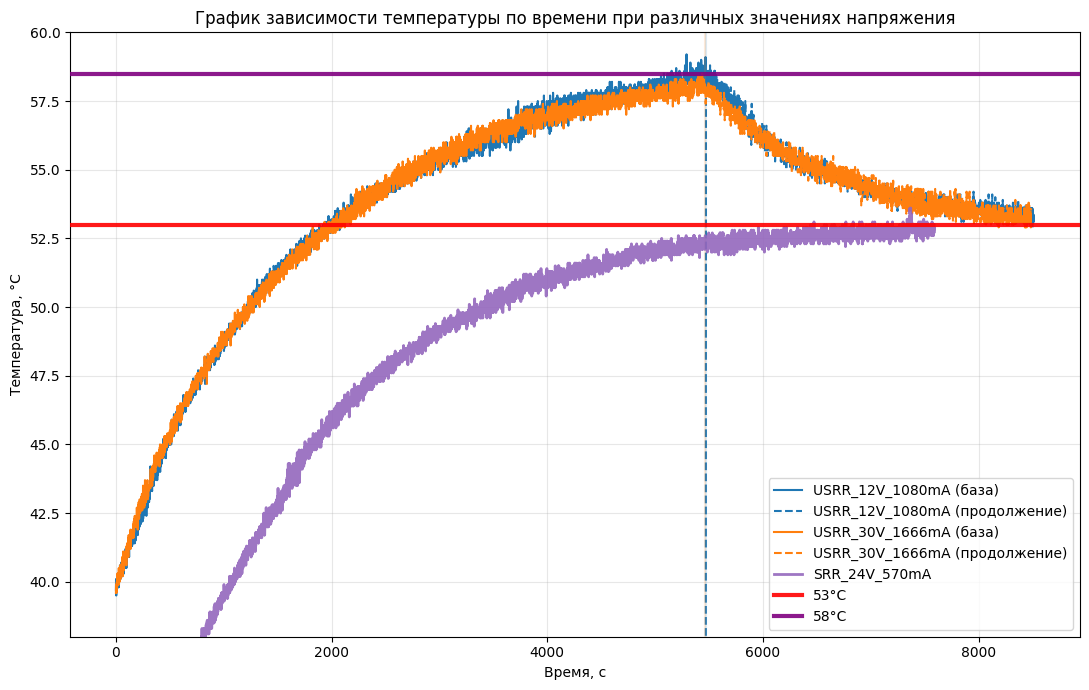

In [11]:
# Продолжение графиков для USRR_12V_1080mA и USRR_30V_1666mA из соответствующих *_to_LRR.csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

base_12 = Path("USRR_12V_1080mA.csv")
cont_12 = Path("USRR_12V_1080mA_to_LRR.csv")
base_30 = Path("USRR_30V_1666mA.csv")
cont_30 = Path("USRR_30V_1666mA_to_LRR.csv")

series = [
    ("USRR_12V_1080mA", base_12, cont_12, "C0"),
    ("USRR_30V_1666mA", base_30, cont_30, "C1"),
]

plt.figure(figsize=(11, 7))
for label, p_base, p_cont, color in series:
    if not p_base.exists():
        print(f"Файл не найден: {p_base}")
        continue
    t_b, y_b = load_time_and_temp(p_base)

    if not p_cont.exists():
        print(f"Файл продолжения не найден: {p_cont}")
        # Рисуем только базовую кривую
        plt.plot(t_b, y_b, label=f"{label}", color=color)
        continue

    t_c, y_c = load_time_and_temp(p_cont)

    if len(t_b) == 0 or len(t_c) == 0:
        print(f"Недостаточно данных в одной из пар: {label}")
        continue

    # Выравнивание по времени: начало продолжения совмещаем с концом базовой
    t_b_end = np.nanmax(t_b)
    t_c_start = np.nanmin(t_c)
    shift = t_b_end - t_c_start
    t_c_shifted = t_c + shift

    # Рисуем
    plt.plot(t_b, y_b, label=f"{label} (база)", color=color)
    plt.plot(t_c_shifted, y_c, label=f"{label} (продолжение)", color=color, linestyle="--")

    # Отметка точки стыка
    # Берём первую валидную точку из продолжения после сдвига
    valid_idx = np.where(~np.isnan(y_c))[0]
    if len(valid_idx) > 0:
        i0 = valid_idx[0]
        plt.scatter([t_c_shifted[i0]], [y_c[i0]], color=color, s=20, zorder=5)
        plt.axvline(t_c_shifted[i0], color=color, alpha=0.15)

# Добавим зависимость SRR_24V на тот же график (если путь задан и файл существует)
try:
    from pathlib import Path as _Path
    srr_path = _Path(SRR_PATH) if 'SRR_PATH' in globals() else _Path('SRR_24V_570mA.csv')
    if srr_path.exists():
        t_srr, y_srr = load_time_and_temp(srr_path)
        plt.plot(t_srr, y_srr, label=srr_path.stem, color='C4', linewidth=2, alpha=0.9)
    else:
        print(f"Файл SRR не найден: {srr_path}")
except Exception as e:
    print(f"Ошибка при добавлении SRR: {e}")

plt.xlabel("Время, с")
plt.ylabel("Температура, °C")
plt.title("График зависимости температуры по времени при различных значениях напряжения")
plt.ylim(38, 60)
plt.axhline(53, color="red", linestyle="-", linewidth=3, alpha=0.9, label="53°C", zorder=5)
plt.axhline(58.5, color="purple", linestyle="-", linewidth=3, alpha=0.9, label="58°C", zorder=5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


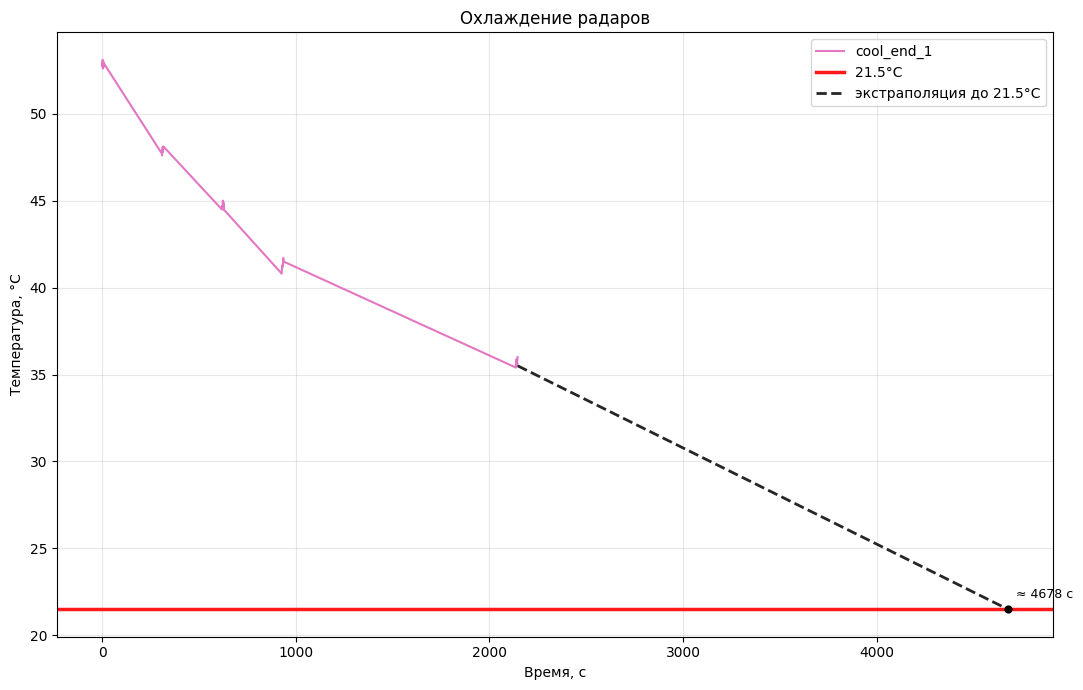

In [13]:
# График из cool_end_1.csv с учётом пауз между десятками (5, 5, 5, 20 минут)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

cool_path = Path("cool_end_1.csv")
if not cool_path.exists():
    raise FileNotFoundError(f"Не найден файл: {cool_path}")

# Читаем данные
cdf = pd.read_csv(cool_path)
if "cpuTemp" not in cdf.columns or "elapsed_seconds" not in cdf.columns:
    raise ValueError("Ожидаемые столбцы 'elapsed_seconds' и 'cpuTemp' не найдены в cool_end_1.csv")

# Отбрасываем NaN
cdf = cdf.copy()
cdf["elapsed_seconds"] = pd.to_numeric(cdf["elapsed_seconds"], errors="coerce")
cdf["cpuTemp"] = pd.to_numeric(cdf["cpuTemp"], errors="coerce")
cdf = cdf.dropna(subset=["elapsed_seconds", "cpuTemp"]).reset_index(drop=True)

n = len(cdf)
if n == 0:
    raise ValueError("В cool_end_1.csv нет валидных данных")

# Разобьём по десяткам записей (каждая партия = 10 измерений)
batch_size = 10
num_batches = int(np.ceil(n / batch_size))
batch_ids = np.arange(n) // batch_size

# Задаём интервалы (в минутах) между партиями: после 1-й — 5 мин, после 2-й — 5, после 3-й — 5, после 4-й — 20
# Первой партии предшествует 0 мин паузы
pause_minutes = [0, 5, 5, 5, 20]
# Если партий больше длины списка, используем последнее значение для всех последующих
if num_batches > len(pause_minutes):
    pause_minutes = pause_minutes + [pause_minutes[-1]] * (num_batches - len(pause_minutes))

# Строим непрерывную шкалу времени: внутри партии используем собственный elapsed_seconds, нормированный к началу партии
t_concat = []
y_concat = []
start_time = 0.0
for b in range(num_batches):
    mask = batch_ids == b
    if not np.any(mask):
        continue
    part = cdf.loc[mask, ["elapsed_seconds", "cpuTemp"]].to_numpy()
    t_part = part[:, 0]
    y_part = part[:, 1]

    # Нормируем время внутри партии к первому значению
    t_part = t_part - t_part[0]

    # Добавляем кумулятивный старт
    t_part = t_part + start_time

    t_concat.append(t_part)
    y_concat.append(y_part)

    # Обновляем старт: конец текущей партии + пауза перед следующей партией
    if b < num_batches - 1:
        pause_sec = float(pause_minutes[b + 1]) * 60.0  # пауза между партией b и b+1
        start_time = float(t_part[-1]) + pause_sec

# Конкатенация
T = np.concatenate(t_concat)
Y = np.concatenate(y_concat)

plt.figure(figsize=(11, 7))
plt.plot(T, Y, label="cool_end_1", color="C6")
plt.xlabel("Время, с")
plt.ylabel("Температура, °C")
plt.title("Охлаждение радаров")

# Горизонтальная линия комнатной температуры
room_temp = 21.5
plt.axhline(room_temp, color="red", linestyle="-", linewidth=2.5, alpha=0.9, label=f"{room_temp}°C")

# Линейная экстраполяция тренда до комнатной температуры по последним точкам
num_tail = min(30, len(T))
if num_tail >= 5:
    t_tail = T[-num_tail:]
    y_tail = Y[-num_tail:]
    a, b = np.polyfit(t_tail, y_tail, 1)  # y ≈ a*t + b
    if a != 0:
        t_cross = (room_temp - b) / a
        if np.isfinite(t_cross):
            t0 = T[-1]
            t1 = max(t_cross, t0 + max(1.0, T[-1] - T[-2] if len(T) >= 2 else 1.0))
            t_line = np.array([t0, t1])
            y_line = a * t_line + b
            plt.plot(t_line, y_line, color="black", linestyle="--", linewidth=2, alpha=0.85, label="экстраполяция до 21.5°C")
            # Метка времени пересечения
            plt.scatter([t1], [a * t1 + b], color="black", s=24, zorder=6)
            if abs(a * t1 + b - room_temp) < 0.6:
                plt.annotate(f"≈ {t1:.0f} с",
                             xy=(t1, room_temp), xytext=(6, 8), textcoords="offset points",
                             fontsize=9, color="black")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
